# Modeling volumetric noise, particles, and alignment consequences
`Experiments`
1. Inspect the reduction in mean noise for all slices when $\theta$-only rotations are introduced
2. Inspect the per-slice noise profiles when $\theta$-only rotations are introduced.
3. Repeat steps 1 and 2 for $\phi$-only variations
4. Repeat the analysis for various interpolation orders (1,2,3,4,5)
5. Repeat the analysis for various bit depths (float32, uint16 and uint8)

**Notes:**
- We should also inspect how the noise changes as a function of radius R in the x-y planes
- Explore the ripple amplitude as a function of $\phi$
- We can sprinkle simulated particles of various contrast and at know locations throughout the volume and measure SNR/CNR before and after alignment

In [1]:
from __future__ import annotations
import copy
import os
import time

from concurrent.futures import ThreadPoolExecutor
from dataclasses import replace
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.ndimage import gaussian_filter1d

import sys

sys.path.append("..")
from particle_sim_tools import (
    Cylinder,
    Noise,
    NoiseSampler,
    ParticleStateMeasurement,
    ParticleTransformationMeasurement,
    ParticleVolumeUint,
    StandardNoiseVolume,
    Volume,
    create_uniform_particle_volume,
    estimate_volume_noise,
)
from particle_experiment_tools import get_mean_from_volume

TARGET_DATA_TYPE = np.uint16
TARGET_STD_SCALE = 0.0166
if TARGET_DATA_TYPE != np.float32:
    TARGET_STD = TARGET_STD_SCALE * np.iinfo(TARGET_DATA_TYPE).max

NUM_THETA_ANGLES = 20
NUM_PHI_ANGLES = 20
MAX_THETA = 5.0
MAX_PHI = 5.0


plt.style.use("dark_background")
available_workers = max(1, (os.cpu_count() or 2) - 2)


## Illustration: Volume with Noise and Cylinder
Optionally, enables rotation to be applied to the cylinder and an unrotation to be applied to confirm the align() method


In [2]:
do_align = False
v_z, v_xy = 128, 256
theta, phi = 10.0, 30.0
noise_std, rho_xy, rho1, rho2 = 0.0166, 0.5, 0.5, 0.2
cyl = Cylinder(
    gray_value=0.5, radius=0.2 * v_xy, height=0.8 * v_z, theta=theta, phi=phi
)
noise = Noise(std=noise_std, rhoxy=rho_xy, rho1=rho1, rho2=rho2)
vol = Volume(np.float32, voxels_z=v_z, voxels_xy=v_xy, noise=noise, cylinder=cyl)

if do_align:
    print("Aligning volume...")
    vol = vol.align(theta=theta, phi=phi)


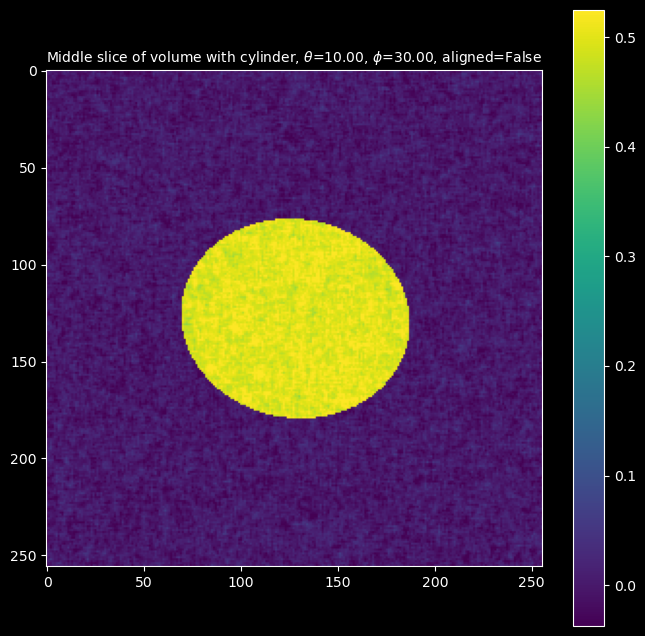

In [3]:
z_mid = vol.data.shape[0] // 2
mid_slice = vol.data[z_mid, :, :]
bounds = vol.valid_bounds
values = mid_slice
if bounds is not None:
    print("Applying bounds for the rotation padding")
    x = np.arange(mid_slice.shape[1])[None, :]
    valid = (x >= bounds.x_min[z_mid, :, None]) & (x < bounds.x_max[z_mid, :, None])
    mid_slice = np.ma.array(mid_slice, mask=~valid)
    cmap = plt.colormaps["gray"].copy()
    cmap.set_bad("black")
    values = mid_slice[valid]
vmin, vmax = np.percentile(values, [1, 99])
plt.figure(figsize=(8, 8))
plt.imshow(mid_slice, vmin=vmin, vmax=vmax)
plt.title(
    rf"Middle slice of volume with cylinder, $\theta$={theta:.2f}, $\phi$={phi:.2f}, aligned={do_align}",
    fontdict={"fontsize": 10},
)
plt.colorbar()
plt.show()

## Noise scaling for $\theta$-only variation
$\theta$ angles are sampled logarithmically to investigate the fall-off at small angles<br>
We inspect the results with various lateral (x-y) dimensions.
**Observations**
1. Noise scaling is not monotonic with theta
2. Mean noise over the slices has increasing oscillation with increasing the lateral dimension v_xy
3. Noise profiles appear to be unaffected with varying $\theta$ (tested for v_z=128, 256, v_xy=256, 512)

In [4]:
execute_theta_cells = False

### Compute the $\theta$-only data

In [5]:
if "theta_noise_ratios_order" not in globals():
    theta_noise_ratios_order = {}
    theta_corr_means_order = {}
    theta_noise_samples_order = {}
    theta_corr_samples_order = {}

TARGET_DATA_TYPE = np.uint8
TARGET_STD = {np.float32: 1.0, np.uint8: 10, np.uint16: 20}
theta_reset = True

if execute_theta_cells:
    if theta_reset:
        theta_noise_ratios_order = {}
        theta_noise_samples_order = {}
        theta_corr_samples_order = {}
        theta_corr_means_order = {}

    max_theta = MAX_THETA
    theta_samples = np.concatenate(
        [[0.0], np.geomspace(0.001, max_theta, num=NUM_THETA_ANGLES)]
    )
    v_xy = 1024
    voxels_z = 64

    # Only one large configuration exists at a time.
    noise_sampler = NoiseSampler(
        v_z=voxels_z,
        v_xy=v_xy,
        analysis_dtype=TARGET_DATA_TYPE,
        target_std=TARGET_STD[TARGET_DATA_TYPE],
    )

    n_workers = min(
        available_workers,
        noise_sampler.get_workers_limit(max_gb=10),
        len(theta_samples),
    )

    for order in [1, 3, 5]:
        if order in theta_noise_samples_order:
            print(f"Order {order} already processed.")
            continue
        total_alignment_time = 0.0

        def process_theta(theta: float, sampler: NoiseSampler) -> tuple:
            """For parallelizing the noise estimation loop"""
            vol = sampler.get_noise_volume()

            start = time.perf_counter()
            vol = vol.align(theta=theta, phi=0.0, order=order)

            alignment_time = time.perf_counter() - start

            noise_estimates, corr_estimates = estimate_volume_noise(vol)

            noise_ratio = np.nanmean(noise_estimates)

            return noise_estimates, corr_estimates, (theta, noise_ratio), alignment_time

        worker = partial(process_theta, sampler=noise_sampler)
        wall_start = time.perf_counter()

        with ThreadPoolExecutor(max_workers=n_workers) as executor:
            results = list(executor.map(worker, theta_samples))

        wall_time = time.perf_counter() - wall_start

        theta_noise_samples = np.array(
            [noise_estimates for noise_estimates, _, _, _ in results]
        )
        theta_corr_samples = np.array(
            [corr_estimates for _, corr_estimates, _, _ in results]
        )
        theta_noise_ratios = np.array([theta_ratio for _, _, theta_ratio, _ in results])

        total_alignment_time = sum(
            alignment_time for _, _, _, alignment_time in results
        )

        sweep_timings = {
            "workers": n_workers,
            "wall_time": wall_time,
            "alignment_worker_time": total_alignment_time,
        }

        print(
            f"  workers={n_workers}, "
            f"wall time={wall_time:.2f}s, "
            f"aggregate alignment time={total_alignment_time:.2f}s"
        )

        theta_noise_ratios_order[order] = (
            theta_noise_ratios  # / theta_noise_ratios[0][1]
        )
        theta_noise_samples_order[order] = (
            theta_noise_samples  # / theta_noise_ratios[0][1]
        )
        theta_corr_samples_order[order] = theta_corr_samples
        theta_corr_means_order[order] = [
            (theta, np.nanmean(corr_estimates))
            for theta, corr_estimates in zip(theta_samples, theta_corr_samples)
        ]

theta_noise_ratios_order = dict(sorted(theta_noise_ratios_order.items()))
theta_noise_samples_order = dict(sorted(theta_noise_samples_order.items()))
theta_corr_samples_order = dict(sorted(theta_corr_samples_order.items()))
theta_corr_means_order = dict(sorted(theta_corr_means_order.items()))
print(
    f"Have completed processing theta noise for orders {theta_noise_ratios_order.keys()} and data type {TARGET_DATA_TYPE}"
)

Have completed processing theta noise for orders dict_keys([]) and data type <class 'numpy.uint8'>


### Plot the mean slice noise reductions for $\theta$-only rotations

In [6]:
if execute_theta_cells:
    fig, ax = plt.subplots(figsize=(18, 8))

    # for v_xy in v_xy_samples[-1:]:
    for key in theta_noise_ratios_order.keys():
        results = theta_noise_ratios_order[key]
        _max = np.max([ratio for _, ratio in results])
        print(f"Max of results is {_max}")

        angles = [theta for theta, ratio in results]
        ratios = [ratio for theta, ratio in results]
        ax.plot(
            angles,
            ratios / _max,
            # marker="o",
            label=rf"$order={key}$",
        )

    ax.set_xlabel(r"$\theta$ (degrees)")
    ax.set_ylabel("Noise ratio")
    ax.grid(True, alpha=0.75)
    """ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )"""

    # fig.subplots_adjust(right=0.8)
    plt.legend()
    plt.ylim(0.800, 1.01)
    plt.xscale("log")
    _dtype = (
        "uint8"
        if TARGET_DATA_TYPE == np.uint8
        else "uint16"
        if TARGET_DATA_TYPE == np.uint16
        else "float32"
    )
    plt.title(
        rf"Mean noise reduction as a function of rotation angle $\theta$ for various interpolation orders (dtype={_dtype})"
    )
    plt.show()

### Plot the mean slice correlations reductions for $\theta$-only rotations

In [7]:
if execute_theta_cells:
    fig, ax = plt.subplots(figsize=(18, 8))

    # for v_xy in v_xy_samples[-1:]:
    for key in theta_corr_means_order.keys():
        results = theta_corr_means_order[key]

        angles = [theta for theta, ratio in results]
        ratios = [corr for theta, corr in results]
        ax.plot(
            angles,
            ratios,
            # marker="o",
            label=rf"$order={key}$",
        )

    ax.set_xlabel(r"$\theta$ (degrees)")
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.75)
    """ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )"""

    # fig.subplots_adjust(right=0.8)
    plt.legend()
    # plt.ylim(0.4, 0.5)
    plt.xscale("log")
    plt.title(
        rf"Mean noise reduction as a function of rotation angle $\theta$ for various interpolation orders (dtype={_dtype})"
    )
    plt.show()

### Plot the noise profiles across slices for $\theta$-only rotations

In [8]:
profile_order = 1
if execute_theta_cells:
    noise_samples = theta_noise_samples_order[profile_order]
    print(type(noise_samples), len(noise_samples), len(noise_samples[0]))

    _slice = slice(0, None, 2)
    angles = theta_samples

    fig, ax = plt.subplots(figsize=(18, 8))
    den = TARGET_STD[TARGET_DATA_TYPE]
    for n_sample, angle in zip(noise_samples[_slice][:], angles[_slice]):
        ax.plot(n_sample / den, label=rf"$\theta$={angle:.4f}")
        # ax.plot(n_sample, label=rf"$\theta$={angle:.4f}")

    ax.set_xlabel("Slice index")
    ax.set_ylabel("Noise")

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )
    ax.grid(True, alpha=0.5)
    fig.subplots_adjust(right=0.8)
    # plt.ylim(0.84, 1.01)
    plt.title(
        rf"Noise across slices for various $\theta$ (order={profile_order}, dtype={_dtype})"
    )


In [9]:
type(noise_samples)

NameError: name 'noise_samples' is not defined

### Plot the correlation profiles across slices for $\theta$-only rotations

In [ ]:
profile_order = 3
if execute_theta_cells:
    corr_samples = theta_corr_samples_order[profile_order]

    _slice = slice(0, None, 4)
    angles = theta_samples

    fig, ax = plt.subplots(figsize=(18, 8))
    den = 1.0
    for n_sample, angle in zip(corr_samples[_slice][:], angles[_slice]):
        ax.plot(n_sample / den, label=rf"$\theta$={angle:.4f}")
        # ax.plot(n_sample, label=rf"$\theta$={angle:.4f}")

    ax.set_xlabel("Slice index")
    ax.set_ylabel("Correlation")

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )
    ax.grid(True, alpha=0.5)
    fig.subplots_adjust(right=0.8)
    # plt.ylim(0.81, 1.01)
    plt.title(
        rf"Correlation across slices for various $\theta$ (order={profile_order})"
    )


## Noise scaling for $\phi$-only variation
$\phi$ angles are sampled logarithmically to investigate the fall-off at small angles<br>
We inspect the results with various lateral (x-y) dimensions.<br>
**Observations**
1. The noise reductions are not monotonic with $\phi$
2. The ripple period for the slice profile is $\frac{1}{2sin(\phi/2)} \approx \frac{57.3}{\theta_{deg}}$
3. The ripple applies to all orders of interplolation, but the amplitude of the ripple decreases significantly with higher order interpolations

In [ ]:
execute_phi_cells = False

### Compute the $\phi$-only data

In [ ]:
if "phi_noise_ratios_order" not in globals():
    phi_noise_ratios_order = {}
    phi_noise_samples_order = {}
    phi_corr_samples_order = {}
    phi_corr_means_order = {}

TARGET_DATA_TYPE = np.uint8
TARGET_STD = {np.float32: 1.0, np.uint8: 10, np.uint16: 20}

phi_reset = True

if execute_phi_cells:
    max_phi = MAX_PHI
    phi_samples = np.concatenate(
        [[0.0], np.geomspace(0.001, max_phi, num=49)]  # NUM_PHI_ANGLES)]
    )
    if phi_reset:
        phi_noise_ratios_order = {}
        phi_noise_samples_order = {}
        phi_corr_samples_order = {}
        phi_corr_means_order = {}

    v_xy = 1024 // 1
    voxels_z = 512 // 1

    # Only one large configuration exists at a time.
    noise_sampler = NoiseSampler(
        v_z=voxels_z,
        v_xy=v_xy,
        analysis_dtype=TARGET_DATA_TYPE,
        target_std=TARGET_STD[TARGET_DATA_TYPE],
    )

    n_workers = min(
        available_workers,
        noise_sampler.get_workers_limit(max_gb=10),
        len(phi_samples),
    )
    print(n_workers)
    for order in [1, 3, 5]:
        if order in phi_noise_samples_order:
            print(f"Order {order} already processed.")
            continue

        total_alignment_time = 0.0
        if order <= 3:
            n_workers = 4
        elif order == 5:
            n_workers = 2

        def process_phi(phi: float, sampler: NoiseSampler) -> tuple:
            """For parallelizing the noise estimation loop"""
            vol = sampler.get_noise_volume()

            start = time.perf_counter()
            vol = vol.align(theta=0.0, phi=phi, order=order)
            alignment_time = time.perf_counter() - start

            noise_estimates, corr_estimates = estimate_volume_noise(vol)
            noise_ratio = np.nanmean(noise_estimates)

            return noise_estimates, corr_estimates, (phi, noise_ratio), alignment_time

        phi_noise_samples = {}
        phi_noise_ratios = {}
        sweep_timings = {}

        worker = partial(process_phi, sampler=noise_sampler)

        wall_start = time.perf_counter()

        with ThreadPoolExecutor(max_workers=n_workers) as executor:
            results = list(executor.map(worker, phi_samples))

        wall_time = time.perf_counter() - wall_start

        phi_noise_samples = np.array(
            [noise_estimates for noise_estimates, _, _, _ in results]
        )
        phi_corr_samples = np.array(
            [corr_estimates for _, corr_estimates, _, _ in results]
        )
        phi_noise_ratios = np.array([phi_ratio for _, _, phi_ratio, _ in results])

        total_alignment_time = sum(
            alignment_time for _, _, _, alignment_time in results
        )

        sweep_timings = {
            "workers": n_workers,
            "wall_time": wall_time,
            "alignment_worker_time": total_alignment_time,
        }

        print(
            f"  workers={n_workers}, "
            f"wall time={wall_time:.2f}s, "
            f"aggregate alignment time={total_alignment_time:.2f}s"
        )

        phi_noise_ratios_order[order] = phi_noise_ratios
        phi_noise_samples_order[order] = phi_noise_samples
        phi_corr_samples_order[order] = phi_corr_samples
        phi_corr_means_order[order] = [
            (phi, np.nanmean(corr_estimates))
            for phi, corr_estimates in zip(phi_samples, phi_corr_samples)
        ]

print(
    f"Have processed orders: {list(phi_noise_samples_order.keys())} with data type {TARGET_DATA_TYPE}"
)

### Plot the mean slice noise reductions for $\phi$-only rotations

In [ ]:
if execute_phi_cells:
    fig, ax = plt.subplots(figsize=(18, 8))

    for key in phi_noise_ratios_order.keys():
        results = phi_noise_ratios_order[key]

        angles = [phi for phi, ratio in results]
        ratios = [ratio for phi, ratio in results]

        ax.plot(
            angles,
            ratios,
            # marker="o",
            label=f"order={key}",
        )

    ax.set_xlabel(r"$\phi$ (degrees)")
    ax.set_ylabel("Noise ratio")
    ax.grid(True, alpha=0.5)

    fig.subplots_adjust(right=0.8)
    # plt.ylim(0.65, 1.01)
    plt.xscale("log")
    plt.title(
        r"Mean noise reduction as a function of rotation angle $\phi$ for various interpolation orders"
    )
    plt.legend()
    plt.show()

### Plot the mean slice correlations for $\phi$-only rotations

In [ ]:
if execute_phi_cells:
    fig, ax = plt.subplots(figsize=(18, 8))

    # for v_xy in v_xy_samples[-1:]:
    for key in phi_corr_means_order.keys():
        results = phi_corr_means_order[key]

        angles = [phi for phi, ratio in results]
        ratios = [corr for phi, corr in results]
        ax.plot(
            angles,
            ratios,
            # marker="o",
            label=rf"$order={key}$",
        )

    ax.set_xlabel(r"$\phi$ (degrees)")
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.75)
    """ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )"""

    # fig.subplots_adjust(right=0.8)
    plt.legend()
    # plt.ylim(0.4, 0.5)
    plt.xscale("log")
    plt.title(
        r"Mean correlation as a function of rotation angle $\phi$ for various interpolation orders"
    )
    plt.show()

### Plot the noise profiles across slices for $\phi$-only rotations

In [ ]:
profile_order = 1

if execute_phi_cells:
    noise_samples = phi_noise_samples_order[profile_order]
    print(type(noise_samples), len(noise_samples), len(noise_samples[0]))

    m = 4
    start = 0
    stop = 44
    step = 10
    _slice = slice(start, stop, step)
    angles = phi_samples

    fig, ax = plt.subplots(figsize=(18, 8))
    for n_sample, angle in zip(noise_samples[_slice][:], angles[_slice]):
        filtered = gaussian_filter1d(n_sample, sigma=2)  # / target_std
        ax.plot(filtered, label=rf"$\phi$={angle:.4f}")
    plt.xlabel("Slice index")
    plt.ylabel("Noise")

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )
    ax.grid(True, alpha=0.5)
    fig.subplots_adjust(right=0.8)
    # plt.ylim(0.60, 1.01)
    _dtype = np.dtype(TARGET_DATA_TYPE).name
    plt.title(
        rf"Noise across slices for various $\phi$ (order={profile_order}, data type={_dtype})"
    )
    plt.show()

### Plot the correlation profiles across slices for $\phi$-only rotations

In [ ]:
profile_order = 5
if execute_phi_cells:
    corr_samples = phi_corr_samples_order[profile_order]

    _slice = slice(0, None, 4)
    angles = phi_samples

    fig, ax = plt.subplots(figsize=(18, 8))
    den = 1.0
    for n_sample, angle in zip(corr_samples[_slice][:], angles[_slice]):
        ax.plot(n_sample / den, label=rf"$\phi$={angle:.4f}")
        # ax.plot(n_sample, label=rf"$\phi$={angle:.4f}")

    ax.set_xlabel("Slice index")
    ax.set_ylabel("Correlation")

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
    )
    ax.grid(True, alpha=0.5)
    fig.subplots_adjust(right=0.8)
    # plt.ylim(0.81, 1.01)
    plt.title(rf"Correlation across slices for various $\phi$ (order={profile_order})")
    plt.show()

## Noise scaling for $\theta$ and $\phi$ variation
Here we sample along both axes to investigate the effect of both rotations on the noise field.

In [ ]:
execute_theta_phi_cells = False

### Compute the $\theta$, $\phi$ data

In [ ]:
if "theta_phi_noise_ratios_order" not in globals():
    theta_phi_noise_ratios_order = {}
    theta_phi_corr_means_order = {}
    theta_phi_noise_samples_order = {}
    theta_phi_corr_samples_order = {}

TARGET_DATA_TYPE = np.uint8
theta_phi_reset = False
if theta_phi_reset:
    theta_phi_noise_ratios_order = {}
    theta_phi_corr_means_order = {}
    theta_phi_noise_samples_order = {}
    theta_phi_corr_samples_order = {}

angles = (0.0, 0.01, 0.1, 1.0)
theta_phi_samples = [(theta, phi) for theta in angles for phi in angles]

if execute_theta_phi_cells and order not in theta_phi_noise_samples_order:
    v_xy = 1024 // 1
    voxels_z = 512 // 1

    noise_sampler = NoiseSampler(
        v_z=voxels_z,
        v_xy=v_xy,
        analysis_dtype=TARGET_DATA_TYPE,
        target_std=TARGET_STD[TARGET_DATA_TYPE],
    )

    n_workers = min(
        available_workers,
        noise_sampler.get_workers_limit(max_gb=10),
        len(theta_phi_samples),
    )

    for order in [1, 3, 5]:
        total_alignment_time = 0.0
        n_workers = 8 if order == 1 else 6 if order == 3 else 3

        def process_theta_phi(
            angle_pair: tuple[float, float], sampler: NoiseSampler
        ) -> tuple:
            """Rotate and estimate noise for one theta-phi pair."""
            theta, phi = angle_pair
            vol = sampler.get_noise_volume()

            start = time.perf_counter()
            vol = vol.align(theta=theta, phi=phi, order=order)
            alignment_time = time.perf_counter() - start

            noise_estimates, corr_estimates = estimate_volume_noise(vol)
            noise_mean = np.nanmean(noise_estimates)
            corr_mean = np.nanmean(corr_estimates)

            return (
                noise_estimates,
                corr_estimates,
                ((theta, phi), noise_mean),
                ((theta, phi), corr_mean),
                alignment_time,
            )

        worker = partial(process_theta_phi, sampler=noise_sampler)

        wall_start = time.perf_counter()
        with ThreadPoolExecutor(max_workers=n_workers) as executor:
            results = list(executor.map(worker, theta_phi_samples))
        wall_time = time.perf_counter() - wall_start

        theta_phi_noise_samples = np.array(
            [noise_estimates for noise_estimates, _, _, _, _ in results]
        )
        theta_phi_corr_samples = np.array(
            [corr_estimates for _, corr_estimates, _, _, _ in results]
        )
        theta_phi_noise_ratios = np.array(
            [noise_result for _, _, noise_result, _, _ in results], dtype=object
        )
        theta_phi_corr_means = np.array(
            [corr_result for _, _, _, corr_result, _ in results], dtype=object
        )

        total_alignment_time = sum(
            alignment_time for _, _, _, _, alignment_time in results
        )
        sweep_timings = {
            "workers": n_workers,
            "wall_time": wall_time,
            "alignment_worker_time": total_alignment_time,
        }

        print(
            f"  workers={n_workers}, "
            f"wall time={wall_time:.2f}s, "
            f"aggregate alignment time={total_alignment_time:.2f}s"
        )

        theta_phi_noise_ratios_order[order] = theta_phi_noise_ratios
        theta_phi_corr_means_order[order] = theta_phi_corr_means
        theta_phi_noise_samples_order[order] = theta_phi_noise_samples
        theta_phi_corr_samples_order[order] = theta_phi_corr_samples

print(
    "Have completed processing theta-phi noise for orders "
    f"{list(theta_phi_noise_samples_order.keys())}"
)


### Plot the mean slice noise reductions for $\theta$-$\phi$ rotations

In [ ]:
if execute_theta_phi_cells:
    orders = sorted(theta_phi_noise_ratios_order)
    all_results = [theta_phi_noise_ratios_order[key] for key in orders]
    all_values = [value for results in all_results for _, value in results]
    value_min, value_max = min(all_values), max(all_values)

    ncols = min(3, len(orders))
    nrows = int(np.ceil(len(orders) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.8 * ncols, 4.2 * nrows),
        squeeze=False,
        layout="constrained",
    )

    for ax, key, results in zip(axes.flat, orders, all_results):
        theta_values = sorted({theta for (theta, _), _ in results})
        phi_values = sorted({phi for (_, phi), _ in results})
        theta_index = {theta: i for i, theta in enumerate(theta_values)}
        phi_index = {phi: i for i, phi in enumerate(phi_values)}
        value_image = np.full(
            (len(phi_values), len(theta_values)), np.nan, dtype=np.float64
        )
        for (theta, phi), value in results:
            value_image[phi_index[phi], theta_index[theta]] = value / value_max

        image = ax.imshow(
            value_image,
            origin="lower",
            cmap="viridis",
            vmin=value_min / value_max,
            vmax=1.0,
            aspect="equal",
        )
        for phi_i, theta_i in np.ndindex(value_image.shape):
            value = value_image[phi_i, theta_i]
            if np.isfinite(value):
                color_fraction = (value - value_min / value_max) / max(
                    1.0 - value_min / value_max, np.finfo(float).eps
                )
                ax.text(
                    theta_i,
                    phi_i,
                    f"{value:.4f}",
                    ha="center",
                    va="center",
                    color="white" if color_fraction < 0.55 else "black",
                )

        ax.set_xticks(range(len(theta_values)), labels=theta_values)
        ax.set_yticks(range(len(phi_values)), labels=phi_values)
        ax.set_xlabel(r"$\theta$ (degrees)")
        ax.set_ylabel(r"$\phi$ (degrees)")
        ax.set_title(f"Interpolation order {key}")

    for ax in list(axes.flat)[len(orders) :]:
        ax.set_visible(False)

    fig.colorbar(image, ax=axes.ravel().tolist(), label="Mean noise", shrink=0.85)
    fig.suptitle(r"Mean noise as a function of $\theta$ and $\phi$")
    plt.show()


### Plot the mean slice correlations for $\theta$-$\phi$ rotations


In [ ]:
if execute_theta_phi_cells:
    orders = sorted(theta_phi_corr_means_order)
    all_results = [theta_phi_corr_means_order[key] for key in orders]
    all_values = [value for results in all_results for _, value in results]
    value_min, value_max = min(all_values), max(all_values)

    ncols = min(3, len(orders))
    nrows = int(np.ceil(len(orders) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.8 * ncols, 4.2 * nrows),
        squeeze=False,
        layout="constrained",
    )

    for ax, key, results in zip(axes.flat, orders, all_results):
        theta_values = sorted({theta for (theta, _), _ in results})
        phi_values = sorted({phi for (_, phi), _ in results})
        theta_index = {theta: i for i, theta in enumerate(theta_values)}
        phi_index = {phi: i for i, phi in enumerate(phi_values)}
        value_image = np.full(
            (len(phi_values), len(theta_values)), np.nan, dtype=np.float64
        )
        for (theta, phi), value in results:
            value_image[phi_index[phi], theta_index[theta]] = value

        image = ax.imshow(
            value_image,
            origin="lower",
            cmap="viridis",
            vmin=value_min,
            vmax=value_max,
            aspect="equal",
        )
        for phi_i, theta_i in np.ndindex(value_image.shape):
            value = value_image[phi_i, theta_i]
            if np.isfinite(value):
                color_fraction = (value - value_min) / max(
                    value_max - value_min, np.finfo(float).eps
                )
                ax.text(
                    theta_i,
                    phi_i,
                    f"{value:.4f}",
                    ha="center",
                    va="center",
                    color="white" if color_fraction < 0.55 else "black",
                )

        ax.set_xticks(range(len(theta_values)), labels=theta_values)
        ax.set_yticks(range(len(phi_values)), labels=phi_values)
        ax.set_xlabel(r"$\theta$ (degrees)")
        ax.set_ylabel(r"$\phi$ (degrees)")
        ax.set_title(f"Interpolation order {key}")

    for ax in list(axes.flat)[len(orders) :]:
        ax.set_visible(False)

    fig.colorbar(image, ax=axes.ravel().tolist(), label="Mean correlation", shrink=0.85)
    fig.suptitle(r"Mean correlation as a function of $\theta$ and $\phi$")
    plt.show()


### Plot the noise profiles across slices for $\theta$-$\phi$ rotations

In [ ]:
profile_order = 5
if execute_theta_phi_cells:
    profiles = theta_phi_noise_samples_order[profile_order]
    profiles_by_angle = dict(zip(theta_phi_samples, profiles, strict=True))
    theta_values = sorted({theta for theta, _ in theta_phi_samples})
    phi_values = sorted({phi for _, phi in theta_phi_samples})

    fig, axes = plt.subplots(
        len(phi_values),
        1,
        figsize=(16, 4 * len(phi_values)),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    for ax, phi in zip(axes[:, 0], phi_values):
        for theta in theta_values:
            ax.plot(
                profiles_by_angle[(theta, phi)] / TARGET_STD[TARGET_DATA_TYPE],
                label=rf"$\theta$={theta:g}°",
            )
        ax.set_ylabel("Noise")
        ax.set_title(rf"$\phi$={phi:g}°, interpolation order={profile_order}")
        ax.grid(True, alpha=0.35)
        ax.legend(title=r"$\theta$", loc="best")

    axes[-1, 0].set_xlabel("Slice index")
    fig.suptitle(
        rf"Noise profiles for combined $\theta$-$\phi$ rotations "
        rf"(order={profile_order}, data_type={np.dtype(TARGET_DATA_TYPE).name})"
    )
    plt.show()


### Plot the correlation profiles across slices for $\theta$-$\phi$ rotations


In [ ]:
profile_order = 5
if execute_theta_phi_cells:
    profiles = theta_phi_corr_samples_order[profile_order]
    profiles_by_angle = dict(zip(theta_phi_samples, profiles, strict=True))
    theta_values = sorted({theta for theta, _ in theta_phi_samples})
    phi_values = sorted({phi for _, phi in theta_phi_samples})

    fig, axes = plt.subplots(
        len(phi_values),
        1,
        figsize=(16, 4 * len(phi_values)),
        sharex=True,
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    for ax, phi in zip(axes[:, 0], phi_values):
        for theta in theta_values:
            ax.plot(
                profiles_by_angle[(theta, phi)],
                label=rf"$\theta$={theta:g}°",
            )
        ax.set_ylabel("Correlation")
        ax.set_title(rf"$\phi$={phi:g}°, interpolation order={profile_order}")
        ax.grid(True, alpha=0.35)
        ax.legend(title=r"$\theta$", loc="best")

    axes[-1, 0].set_xlabel("Slice index")
    fig.suptitle(
        rf"Correlation profiles for combined $\theta$-$\phi$ rotations "
        rf"(order={profile_order})"
    )
    plt.show()


## Particle Analysis

### Simulated Particles
Simulated particles are continuous, axis-aligned Gaussian blobs whose centers may lie at integer or sub-voxel `(z, y, x)` coordinates. `spatial_sigma` may be a positive scalar for an isotropic particle or three positive values in `(z, y, x)` order. Rasterization integrates the Gaussian over each intersecting voxel, truncates it with an ellipsoid in sigma-normalized coordinates, and uses `peak_voxel` normalization so that the strongest original support voxel equals `amplitude_snr`. The floating particle volume therefore represents signal only, with no background or noise.

A newly constructed `Particle` is always unrotated: `theta == phi == 0`. These fields are not constructor arguments. `ParticleVolume.rotate()` applies exactly the same centered, `reshape=False` coordinate sequence as `Volume.align`: `theta` in the `(y, x)` plane followed by `-phi` in the `(z, x)` plane. It returns a new `ParticleVolume`; each copied particle records the requested angles and has an eagerly updated continuous `position_zyx`. This avoids requiring downstream consumers to reinterpret an original position using the volume center. The original particle and volume are unchanged.

The original `support_values` describe the analytically rasterized particle and are not valid after image interpolation. A rotated particle therefore marks these values dirty, and accessing `support_values` raises `RuntimeError`. Rotated particles are tracking/measurement objects and must not be reinjected into another volume.

For a rotated particle, `support_zyx` contains the rounded, clipped transformation of its geometric support and `measurement_support_top_k` separately contains the compact measurement support. The original support is transformed into an output-space bounding region, expanded by an interpolation-order halo, and clipped to the output shape. The strongest `top_k` locations are then selected from the actual rotated particle-only volume—not from stale analytical values and not from a noisy combined volume. This makes the selected locations follow interpolation-induced peak movement. `measurement_top_k` records the number retained.

`ParticleStateMeasurement` identifies a state with `(bit_depth, theta, phi)`. Its top-k candidate locations come from the matching particle-only state: directly from the unrotated support for an original particle, or from `measurement_support_top_k` for a rotated particle. It stores both the particle-only reference values and the values sampled from the quantized combined particle-plus-noise volume at those same locations. The operational peak samples the combined volume at the strongest particle-only location, so noise cannot change which top-k candidate supplies the peak. A top-k sum is a compact core measurement rather than total Gaussian mass, since signal outside the strongest k voxels is excluded. This particle-only attribution assumes particle search regions do not overlap; overlapping particles require separate per-particle signal layers.

## Simulations
`Create FP32 data`<br>
  **Particle volume:** particles spaced uniformly on radial arms separated by a common degree step and placed uniformly throughout z<br>
  **Noise volume:** the standard background noise of unit variance with correlations in the 3 dimensions<br>
  **Combined volume:** the sum of particles and noise<br><br>
`Quantization`<br>
  **Particle volume:** As reference - without noise interference<br>
  **Noise volume:** for extracting noise statistics for SNR measures<br>
  **Combined volume:** the volume for metrics extraction<br>
<br>
`Rotation`<br>
  **Particle volume:**  As a reference to assess popure particle contrast change relative to no rotation<br>
  **Noise volume:** for extracting noise statistics in the rotated volume for SNR measures in rotated space<br>
  **Combined volume:** the volume for metrics extraction in rotated space<br>


### Simulation Configuration

In [158]:
class SimConfig:
    interp_order: int = 1  # Order of the interpolation performed in the rotation

    v_z: int = 128
    v_xy: int = 512
    uint_type: type = np.uint8

    spatial_sigma: float = 2.0
    amplitude: float = 10.0  # Particle SNR

    # Relative values for positioning particles in the z-slices
    z_start_rel: float = 1 / 2  # The relative starting position along the z-axis
    z_end_rel: float = 0.0  # The relative ending position along the z-axis
    z_delta_rel: float = -1 / 8  # The relative spacing of particle x-y planes

    delta_angle_deg: float = 15.0  # Particle radial arm sample spacing
    stop_angle_deg: float = 90.0  # Maximum particle rotation angle

    rotate_angle_theta_deg: float = 1.0  # Azimuthal alignment angle
    rotate_angle_phi_deg: float = 0.0  # Tilt alignment angle

    target_std_scale: float = 4 / 255.0  # For 4.0 sigma
    rho1_z: float = 0.5  # First order lag in the z-direction
    rho1_xy: float = 0.5  # First order lag in the xy-direction

    measurement_top_k: int = (
        7  # Number of the highest particle measurements to consider
    )

    random_seed: int = 9 + 1  # For repeatable random realizations of noise


sim_cfg = SimConfig()
sim_cfg.rotate_angle_theta_deg = 15

### The FP 32 data

In [159]:
particle_volume_fp32 = create_uniform_particle_volume(
    voxels_z=sim_cfg.v_z,
    voxels_xy=sim_cfg.v_xy,
    sigma=sim_cfg.spatial_sigma,
    amplitude=sim_cfg.amplitude,
    z_start_rel=sim_cfg.z_start_rel,
    z_end_rel=sim_cfg.z_end_rel,
    delta_z_rel=sim_cfg.z_delta_rel,
    delta_angle_deg=sim_cfg.delta_angle_deg,
    stop_angle_deg=sim_cfg.stop_angle_deg,
    measurement_top_k=sim_cfg.measurement_top_k,
)

np.random.seed(sim_cfg.random_seed)
noise_volume_fp32 = StandardNoiseVolume(
    voxels_z=sim_cfg.v_z,
    voxels_xy=sim_cfg.v_xy,
    rho1_z=sim_cfg.rho1_z,
    rho1_xy=sim_cfg.rho1_xy,
)

combined_volume_fp32 = copy.deepcopy(particle_volume_fp32)
cv = combined_volume_fp32.get_array()
cv += noise_volume_fp32.get_array()

### Quantized Uint Data

In [160]:
particle_volume_uint = ParticleVolumeUint(
    particle_volume_fp32,
    type=sim_cfg.uint_type,
    target_std_scale=sim_cfg.target_std_scale,
)
print(
    f"Maximum particle value (uint) created: {particle_volume_uint.get_array().max()}"
)
combined_volume_uint = ParticleVolumeUint(
    combined_volume_fp32,
    type=sim_cfg.uint_type,
    target_std_scale=sim_cfg.target_std_scale,
)
print(
    f"Maximum combined volume value (uint) created: {combined_volume_uint.get_array().max()}"
)
# Create the noise volume using the target standard deviation from the ParticleVolumeUint target_scale
target_std = np.iinfo(sim_cfg.uint_type).max * combined_volume_uint.target_std_scale
noise_volume_uint = noise_volume_fp32.get_quantized_noise(
    uint_type=sim_cfg.uint_type, target_std=target_std
)
print(f"Maximum noise volume value (uint) created: {noise_volume_uint.data.max()}")

Maximum particle value (uint) created: 168
Maximum combined volume value (uint) created: 177
Maximum noise volume value (uint) created: 148


### Rotated Data

In [161]:
print(
    f"Rotations \u03b8={sim_cfg.rotate_angle_theta_deg}, \u03c6={sim_cfg.rotate_angle_phi_deg} are performed with order={sim_cfg.interp_order}"
)
rotated_particle_volume_uint = particle_volume_uint.rotate(
    theta=sim_cfg.rotate_angle_theta_deg,
    phi=sim_cfg.rotate_angle_phi_deg,
    order=sim_cfg.interp_order,
)

rotated_combined_volume_uint = combined_volume_uint.rotate(
    theta=sim_cfg.rotate_angle_theta_deg,
    phi=sim_cfg.rotate_angle_phi_deg,
    order=sim_cfg.interp_order,
)

rotated_noise_volume_uint = noise_volume_uint.align(
    theta=sim_cfg.rotate_angle_theta_deg,
    phi=sim_cfg.rotate_angle_phi_deg,
    order=sim_cfg.interp_order,
)


Rotations θ=15, φ=0.0 are performed with order=1


In [162]:
print("Noise mean and std after quantization: ")
print(
    f"Original Noise Volume: mean={noise_volume_uint.data.ravel().mean():.3f}, std={noise_volume_uint.data.ravel().std():.3f}"
)

# For the rotated data, mask off the padded values of zero from the rotation
data = rotated_noise_volume_uint.data.ravel()
valid_mask = data != 0
print(
    f"Rotated Noise Volume: mean={data[valid_mask].mean():.3f}, std={data[valid_mask].std():.3f}"
)
print(
    f"Reduction in the std: {data[valid_mask].std() / noise_volume_uint.data.ravel().std():.3f}"
)


Noise mean and std after quantization: 
Original Noise Volume: mean=127.500, std=4.000
Rotated Noise Volume: mean=127.499, std=3.344
Reduction in the std: 0.836


### Estimate noise from the noise volumes
`estimate_volume_noise()` estimates the per-plane noise from adjacent z-slice differences, estimates the lag-1 z-correlation from the data, and applies the corresponding correlation correction. The first and last plane statistics are copied from their nearest interior planes. For rotated volumes, the estimator uses the volume's valid bounds to exclude zero padding introduced by rotation.

In [163]:
noise_profile_uint, noise_correlation_uint = estimate_volume_noise(noise_volume_uint)
rotated_noise_profile_uint, rotated_noise_correlation_uint = estimate_volume_noise(
    rotated_noise_volume_uint
)
noise_profile_fp32, noise_correlation_fp32 = estimate_volume_noise(
    noise_volume_fp32.sampler.noise_vol
)

mean_noise_uint = np.nanmean(noise_profile_uint)
mean_rotated_noise_uint = np.nanmean(rotated_noise_profile_uint)
mean_corr_uint = np.nanmean(noise_correlation_uint)
print(f"Mean noise uint: {mean_noise_uint:.3f}")
print(f"Mean noise rotated uint: {mean_rotated_noise_uint:.3f}")
print(f"Mean correlation uint: {mean_corr_uint:.3f}")
mean_corr_rotated_uint = np.nanmean(rotated_noise_correlation_uint)
print(f"Mean correlation rotated uint: {mean_corr_rotated_uint:.3f}")
print(
    f"Reduction factor for correlation: {mean_corr_rotated_uint / mean_corr_uint:.3f}"
)
print(f"Reduction factor: {mean_rotated_noise_uint / mean_noise_uint:.3f}")

Mean noise uint: 4.000
Mean noise rotated uint: 3.344
Mean correlation uint: 0.497
Mean correlation rotated uint: 0.495
Reduction factor for correlation: 0.995
Reduction factor: 0.836


### Illustrations
Plots of radial slices

Fixing image with title 'rotated_particle_volume_uint' due to zero padding
Fixing image with title 'rotated_combined_volume_uint' due to zero padding


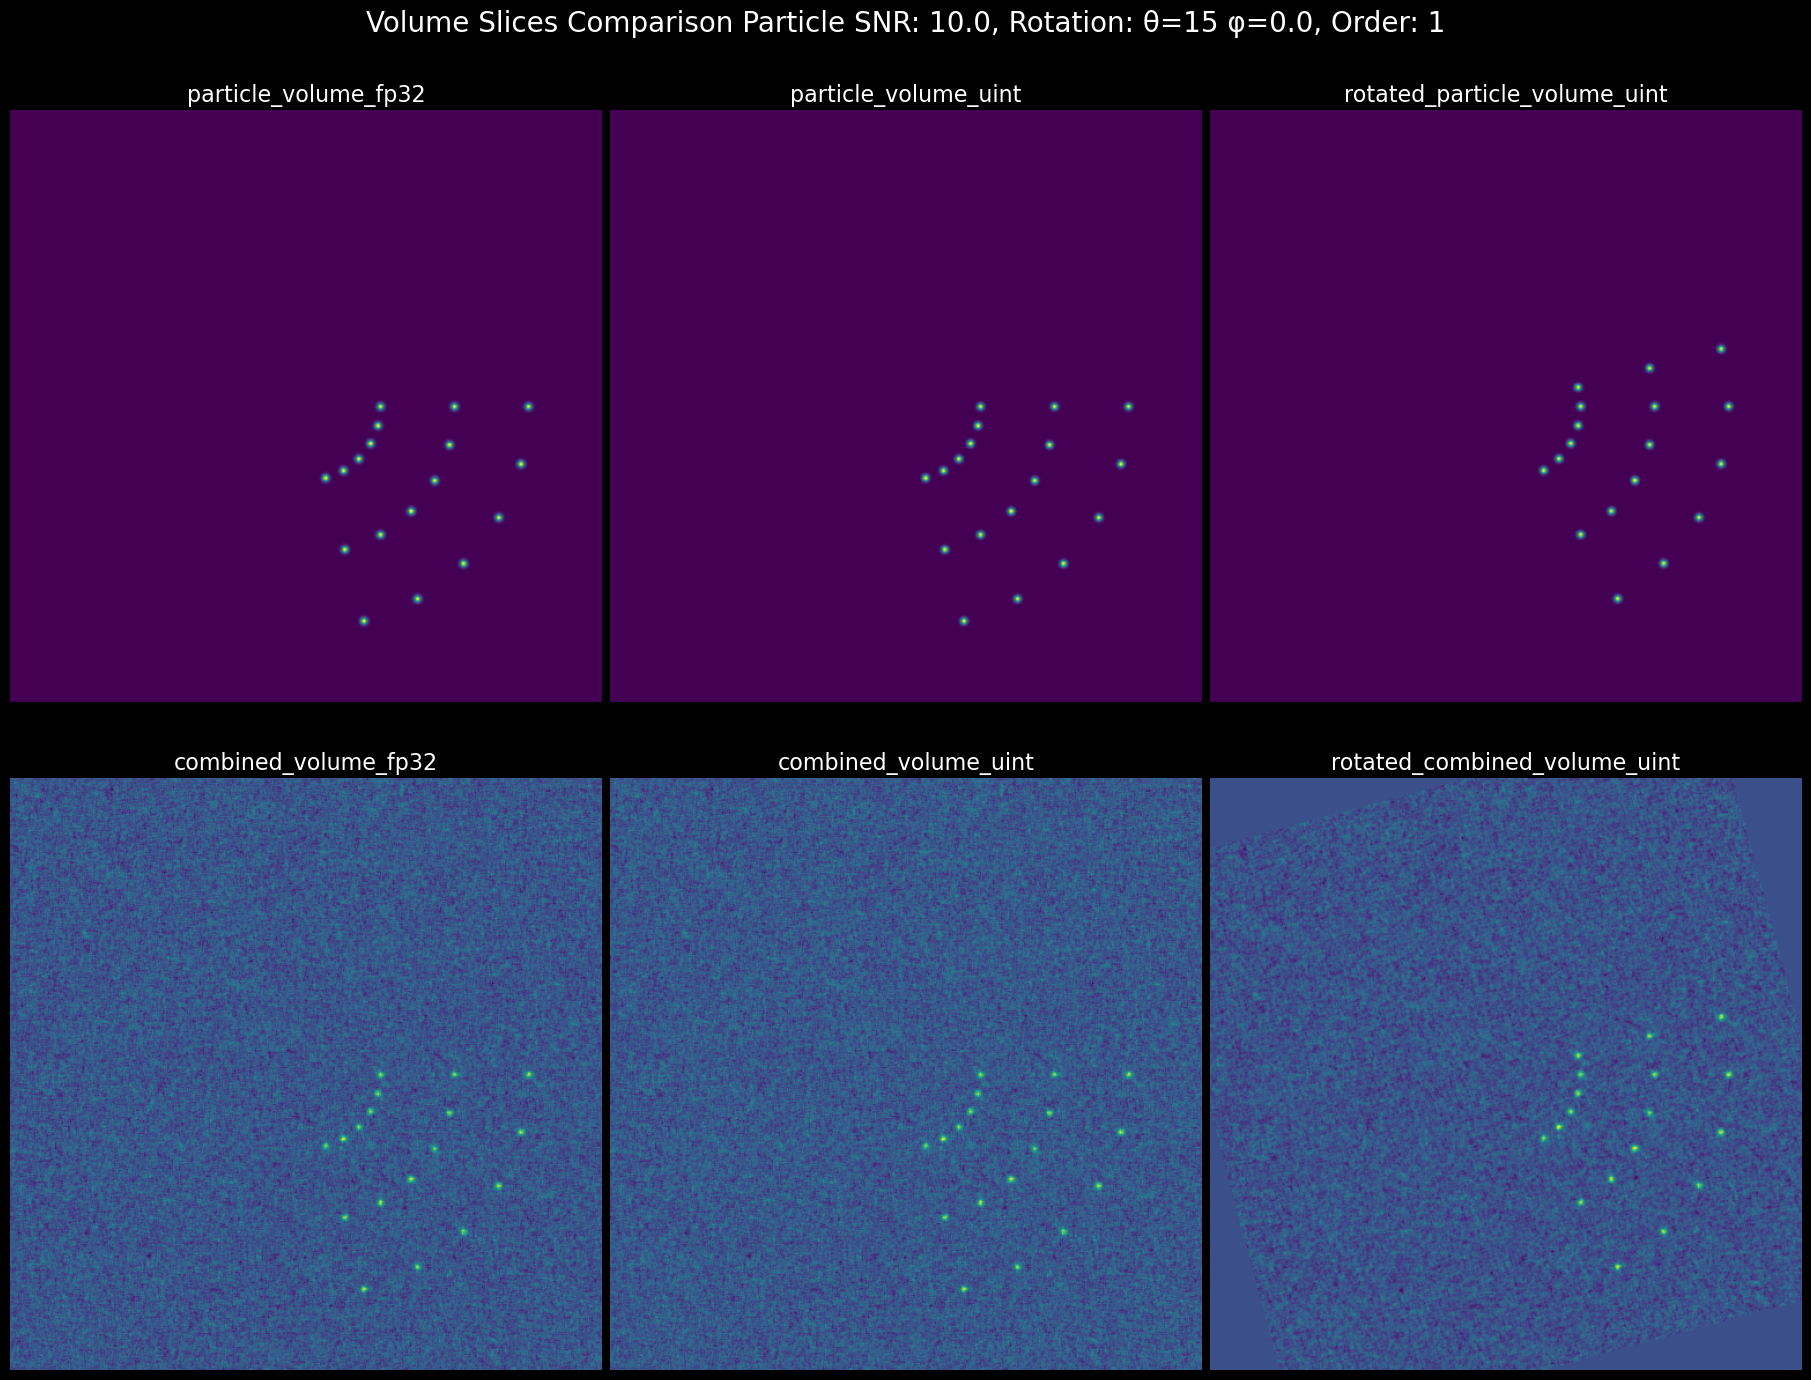

In [164]:
volume_list = [
    particle_volume_fp32,
    particle_volume_uint,
    rotated_particle_volume_uint,
    combined_volume_fp32,
    combined_volume_uint,
    rotated_combined_volume_uint,
]
title_list = [
    "particle_volume_fp32",
    "particle_volume_uint",
    "rotated_particle_volume_uint",
    "combined_volume_fp32",
    "combined_volume_uint",
    "rotated_combined_volume_uint",
]

vol_shape = particle_volume_fp32.volume.data.shape
z_pos = vol_shape[0] // 2 - 1 * vol_shape[0] // 8
image_list = [vol.volume.data[z_pos] for vol in volume_list]

# region Plotting
layout = [
    [
        title_list[0],
        title_list[0],
        title_list[1],
        title_list[1],
        title_list[2],
        title_list[2],
    ],
    [
        title_list[3],
        title_list[3],
        title_list[4],
        title_list[4],
        title_list[5],
        title_list[5],
    ],
]

fig, axes = plt.subplot_mosaic(
    layout,
    figsize=(18, 14),
    layout="constrained",
)
fig.suptitle(
    f"Volume Slices Comparison Particle SNR: {sim_cfg.amplitude}, Rotation: θ={sim_cfg.rotate_angle_theta_deg} φ={sim_cfg.rotate_angle_phi_deg}, Order: {sim_cfg.interp_order}\n",
    fontsize=20,
)
for title, image in zip(title_list, image_list):
    ax = axes[title]

    # We have to fix the rotated images with padded zeros
    _image = image
    if not (image.dtype == np.float32) and (np.sum(image == 0) > 10):
        print(f"Fixing image with title '{title}' due to zero padding")
        _image = image.copy()
        _image[image == 0] = image[image > 0].mean()

    ax.imshow(_image, cmap="viridis")
    ax.set_title(title, fontsize=16)
    ax.axis("off")
plt.show()
# endregion

Noise Profiles

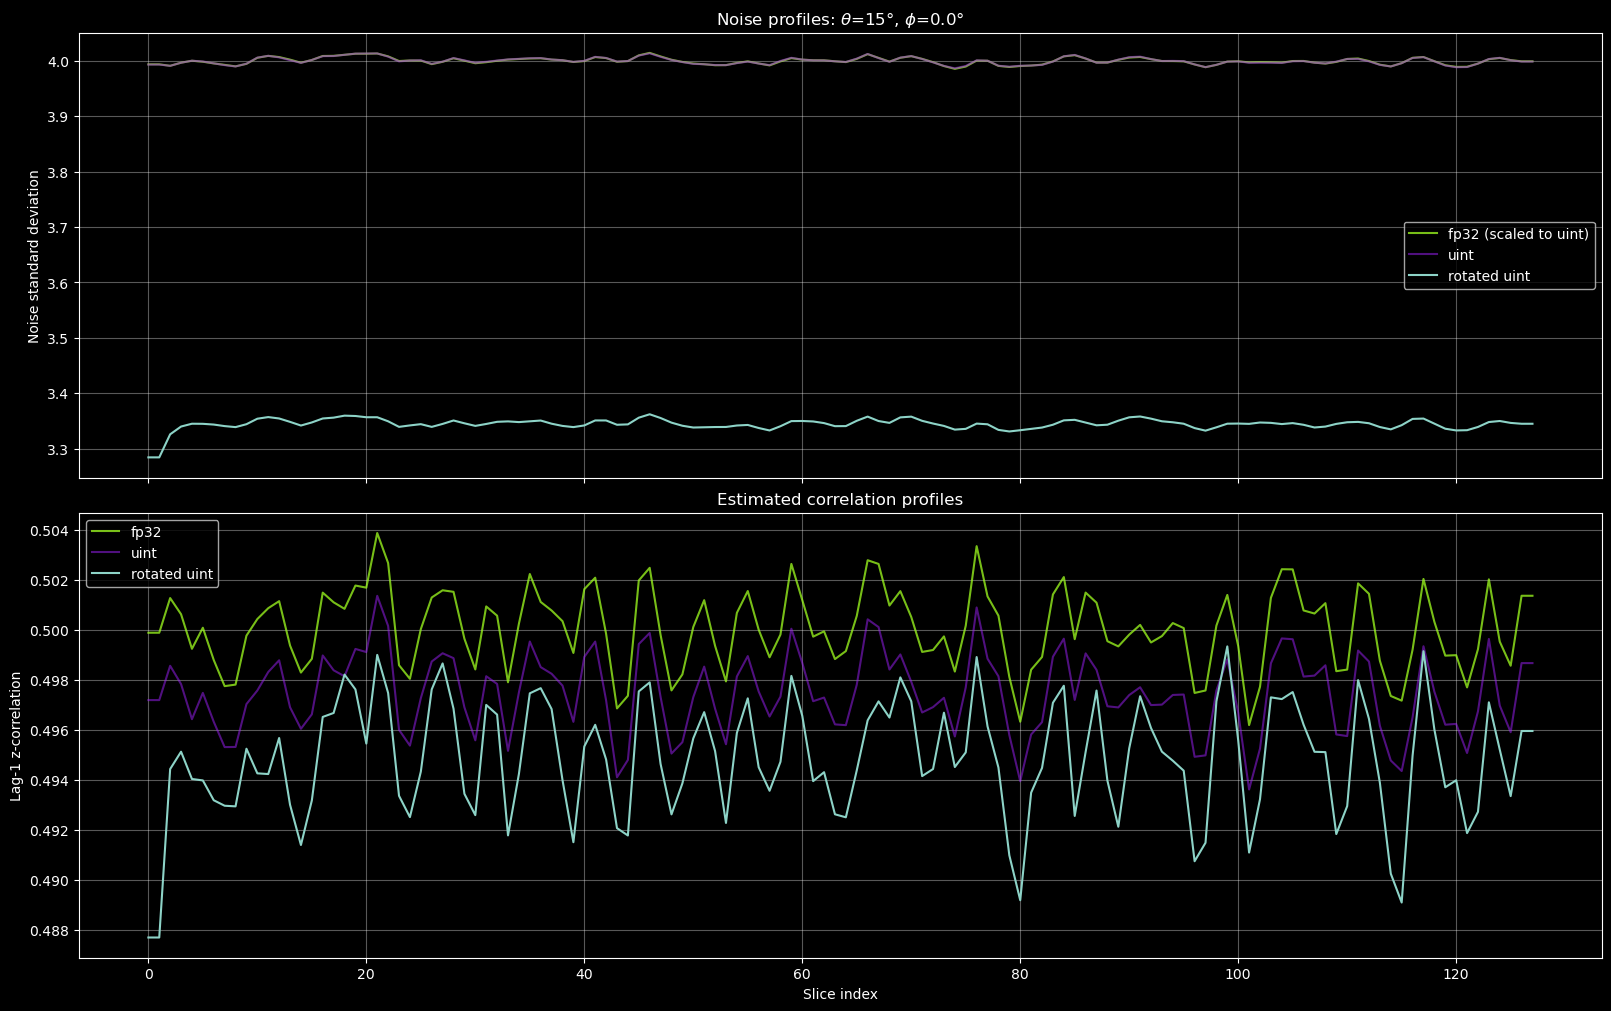

In [165]:
# Scale the unit-noise FP32 profile into the observed uint noise space.
fp32_to_uint_scale = np.nanmean(noise_profile_uint) / np.nanmean(noise_profile_fp32)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, layout="constrained")
axes[0].plot(
    noise_profile_fp32 * fp32_to_uint_scale,
    color="#A0FF20",
    label="fp32 (scaled to uint)",
    alpha=0.75,
)
axes[0].plot(noise_profile_uint, label="uint", color="#A020FF", alpha=0.5)
axes[0].plot(rotated_noise_profile_uint, label="rotated uint")
axes[0].set_ylabel("Noise standard deviation")
axes[0].legend()
axes[0].grid(True, alpha=0.35)
axes[0].set_title(
    rf"Noise profiles: $\theta$={sim_cfg.rotate_angle_theta_deg}°, "
    rf"$\phi$={sim_cfg.rotate_angle_phi_deg}°"
)

axes[1].plot(noise_correlation_fp32, color="#A0FF20", label="fp32", alpha=0.75)
axes[1].plot(noise_correlation_uint, color="#A020FF", label="uint", alpha=0.5)
axes[1].plot(rotated_noise_correlation_uint, label="rotated uint")
axes[1].set_xlabel("Slice index")
axes[1].set_ylabel("Lag-1 z-correlation")
axes[1].legend()
axes[1].grid(True, alpha=0.35)
axes[1].set_title("Estimated correlation profiles")
plt.show()

### Metric Calculations
Compute metrics from the combined objects in FP32, UINT and UINT-rotated

In [166]:
measurements_fp32 = [
    ParticleStateMeasurement.from_particle(
        particle,
        particle_only_data=particle_volume_fp32.get_array(),
        combined_data=combined_volume_fp32.get_array(),
        state=(np.float32, 0.0, 0.0),
        noise_mean=0.0,
        noise_std_profile=noise_profile_fp32,
        top_k=sim_cfg.measurement_top_k,
    )
    for particle in combined_volume_fp32.particles
]

noise_mean_uint = get_mean_from_volume(noise_volume_uint.data)
measurements_uint = [
    ParticleStateMeasurement.from_particle(
        particle,
        particle_only_data=particle_volume_uint.get_array(),
        combined_data=combined_volume_uint.get_array(),
        state=(sim_cfg.uint_type, 0.0, 0.0),
        noise_mean=noise_mean_uint,
        noise_std_profile=noise_profile_uint,
        top_k=sim_cfg.measurement_top_k,
    )
    for particle in combined_volume_uint.particles
]

rotated_noise_mean_uint = get_mean_from_volume(rotated_noise_volume_uint.data)
measurements_uint_rotated = [
    ParticleStateMeasurement.from_particle(
        particle,
        particle_only_data=rotated_particle_volume_uint.get_array(),
        combined_data=rotated_combined_volume_uint.get_array(),
        state=(
            sim_cfg.uint_type,
            sim_cfg.rotate_angle_theta_deg,
            sim_cfg.rotate_angle_phi_deg,
        ),
        noise_mean=rotated_noise_mean_uint,
        noise_std_profile=rotated_noise_profile_uint,
        top_k=sim_cfg.measurement_top_k,
    )
    for particle in rotated_particle_volume_uint.particles
]


### Compare metrics
uint vs fp32<br>
uint vs uint rotated

In [167]:
particle_transformation_measurements_uint_to_rotated = []

for muint, muint_rot in zip(measurements_uint, measurements_uint_rotated):
    particle_transformation_measurements_uint_to_rotated.append(
        ParticleTransformationMeasurement(before=muint, after=muint_rot)
    )


In [168]:
particle_metrics_table = pd.DataFrame(
    [
        {
            "particle_id": measurement.before.particle_id,
            "z": measurement.before.position_zyx[0],
            "y": measurement.before.position_zyx[1],
            "x": measurement.before.position_zyx[2],
            "peak_cnr_before": measurement.before.peak_cnr,
            "peak_cnr_after": measurement.after.peak_cnr,
            "peak_cnr_retention": measurement.peak_cnr_retention,
            "integrated_cnr_before": measurement.before.integrated_cnr,
            "integrated_cnr_after": measurement.after.integrated_cnr,
            "integrated_cnr_retention": measurement.integrated_cnr_retention,
            "integrated_contrast_before": measurement.before.integrated_contrast,
            "integrated_contrast_after": measurement.after.integrated_contrast,
            "integrated_contrast_retention": measurement.integrated_contrast_retention,
            "integrated_contrast_drop": measurement.integrated_contrast_drop,
            "peak_before": measurement.before.peak_contrast,
            "peak_after": measurement.after.peak_contrast,
            "peak_contrast_retention": measurement.peak_contrast_retention,
            "peak_contrast_drop": measurement.peak_contrast_drop,
        }
        for measurement in particle_transformation_measurements_uint_to_rotated
    ]
).set_index("particle_id")

display(particle_metrics_table.style.format(precision=3))


,z,y,x,peak_cnr_before,peak_cnr_after,peak_cnr_retention,integrated_cnr_before,integrated_cnr_after,integrated_cnr_retention,integrated_contrast_before,integrated_contrast_after,integrated_contrast_retention,integrated_contrast_drop,peak_before,peak_after,peak_contrast_retention,peak_contrast_drop
particle_id,,,,,,,,,,,,,,,,,
0,64.000,256.000,320.000,10.380,11.524,1.110,23.769,27.199,1.144,251.498,240.504,0.956,0.044,41.500,38.501,0.928,0.072
1,64.000,256.000,384.000,11.380,12.722,1.118,26.888,30.479,1.134,284.498,269.504,0.947,0.053,45.500,42.501,0.934,0.066
2,64.000,256.000,448.000,10.130,11.225,1.108,22.919,26.170,1.142,242.498,231.504,0.955,0.045,40.500,37.501,0.926,0.074
3,64.000,272.564,317.819,9.379,10.626,1.133,23.103,26.520,1.148,244.498,234.504,0.959,0.041,37.500,35.501,0.947,0.053
4,64.000,289.129,379.639,11.130,11.524,1.035,25.186,28.556,1.134,266.498,252.504,0.947,0.053,44.500,38.501,0.865,0.135
5,64.000,305.693,441.458,9.379,10.926,1.165,22.823,26.973,1.182,241.498,238.504,0.988,0.012,37.500,36.501,0.973,0.027
6,64.000,288.000,311.426,10.630,10.926,1.028,25.371,28.895,1.139,268.498,255.504,0.952,0.048,42.500,36.501,0.859,0.141
7,64.000,320.000,366.851,9.630,11.524,1.197,24.337,29.348,1.206,257.498,259.504,1.008,-0.008,38.500,38.501,1.000,-0.000
8,64.000,352.000,422.277,10.380,11.225,1.081,24.904,28.431,1.142,263.498,251.504,0.954,0.046,41.500,37.501,0.904,0.096


In [169]:
attributes = [
    name
    for name in dir(particle_transformation_measurements_uint_to_rotated[0])
    if not name.startswith("_")
]
attributes

['after',
 'before',
 'integrated_cnr_retention',
 'integrated_contrast_drop',
 'integrated_contrast_retention',
 'peak_cnr_retention',
 'peak_contrast_drop',
 'peak_contrast_retention']

## Particle noise and rotation sweep

The sweep uses a fixed particle geometry for every condition. Particles occupy the central z-slice and three evenly spaced slices toward the top of the volume. Each slice contains three radial positions on arms spaced by 15 degrees within one quadrant.

For each bit depth, noise seed, and `(theta, phi)` pair, the table records one paired before/after comparison. `noise_seed == NO_NOISE_SEED` is the flat noise-mean baseline; every nonnegative seed is a realized-noise run.

The shared metric columns therefore have the same meaning for every run. For the sentinel row they measure rotation/interpolation on the flat-background particle volume; for realized seeds they measure the particle-plus-noise volume at locations selected from the matching particle-only state. Noise effects can be computed by joining each realized row to its matching sentinel row.

Execution is organized one bit depth at a time. Clean particle measurements are rotated once per particle condition and reused across seeds. Each noise realization is generated and rotated once per seed and bit depth, then its mean and profile are reused across all particle sigma/SNR combinations. Particle-plus-noise rotations remain specific to a seed and particle condition.

Noise rotations and noise estimation use the full x-y particle-bearing z-slab. Clean particle-only and particle-plus-noise rotations use conservative, independent particle neighborhoods while preserving the full-volume rotation center. The main thread writes each completed condition to `../Data/simulated_particles/particle_experiment_metrics_neighborhood_optimized.csv` and updates the progress display.

The detailed sweep is not retained as a full in-memory DataFrame. A completed run returns the CSV path, row count, elapsed time, and a compact timing table. Summary statistics are queried directly from the CSV.

The full Cartesian sweep contains 990 conditions per seed before expanding to individual particles. At `1024 x 512 x 512` in `(z, y, x)` order, this is still a large production run, so execution is opt-in below. Begin with the pilot and five paired seeds; increase the number of seeds until the reported confidence intervals are sufficiently narrow.

In [170]:
from scripts.particle_sim_sweep import particle_sweep_config
from particle_experiment_tools import (
    NO_NOISE_SEED,
    run_particle_rotation_sweep_particle_neighborhoods,
    validate_particle_neighborhood_optimization,
    PARTICLE_SWEEP_OUTPUT_CSV,
)


### Optimized implementation

The production implementation rotates and estimates noise in the full x-y particle-bearing z-slab, while rotating clean particle-only and particle-plus-noise data in independent particle neighborhoods. Every neighborhood preserves the two-stage theta-then-phi interpolation, uses the full-volume rotation center, and includes a conservative 32-voxel spline halo. The bounded worker pool can process particle neighborhoods concurrently without scheduling all high-order transforms at once.

This is the canonical sweep workflow. Its metrics are written to the standard experiment CSV.

### Validation

In [22]:
particle_neighborhood_validation = validate_particle_neighborhood_optimization()
particle_neighborhood_validation

Writing optimized particle metrics to /Users/jim/Documents/GitHub/particles/Notebooks/Data/_tmp/particle_neighborhood_slab_reference.csv
z slabs: input=[0, 166) (166/192), output=[4, 125) (121/192); rotation workers=2


Particle z-slab sweep:   0%|          | 0/8 [00:00<?, ?condition/s]

NameError: name 'condition_is_pending' is not defined

### Pilot timing

This runs the canonical particle-neighborhood implementation with a small configuration. The measured order-5 runtime was about 130.4 seconds per condition; order 3 and order 1 were about 59.3 and 46.3 seconds, respectively.

In [23]:
particle_sweep_pilot_config = replace(
    particle_sweep_config,
    particle_sigmas=(2.0,),
    amplitude_snrs=(5.0,),
    interpolation_orders=(3,),
    bit_depths=(np.uint8,),
    theta_angles_deg=(15.0,),
    phi_angles_deg=(0.1, 1.0),
    noise_seeds=(NO_NOISE_SEED, 10),
)

particle_neighborhood_experiment_run = (
    run_particle_rotation_sweep_particle_neighborhoods(
        particle_sweep_pilot_config,
        output_csv=PARTICLE_SWEEP_OUTPUT_CSV,
    )
)
pilot_condition_count = (
    len(particle_sweep_pilot_config.noise_seeds)
    * len(particle_sweep_pilot_config.bit_depths)
    * len(particle_sweep_pilot_config.particle_sigmas)
    * len(particle_sweep_pilot_config.amplitude_snrs)
    * len(particle_sweep_pilot_config.interpolation_orders)
    * len(particle_sweep_pilot_config.theta_angles_deg)
    * len(particle_sweep_pilot_config.phi_angles_deg)
)
print(
    f"Mean time per condition: "
    f"{particle_neighborhood_experiment_run.elapsed_seconds / pilot_condition_count:.1f}s"
)

Writing particle-neighborhood metrics to /Users/jim/Documents/GitHub/particles/Notebooks/Data/simulated_particles/particle_experiment_metrics.csv
noise z slabs: input=[71, 577) (506/1024), output=[112, 536) (424/1024); noise workers=2, particle workers=8, particle halo=32


Particle-neighborhood sweep:   0%|          | 0/4 [00:00<?, ?condition/s]


Particle-neighborhood timing summary (seconds):
                                                          compute_seconds  write_seconds  elapsed_seconds
phase                                interpolation_order                                                 
clean_rotation_particle_neighborhood 3.0                         0.440928       0.005474         0.446402
clean_setup_particle_neighborhood    NaN                         2.070377       0.000000         2.070377
noise_rotation_z_slab                3.0                        78.199193       0.000000        78.199193
noise_setup_z_slab                   NaN                        74.373397       0.000000        74.373397
noisy_rotation_particle_neighborhood 3.0                         0.220222       0.003573         0.223795
noisy_setup_particle_neighborhood    NaN                         2.254006       0.000000         2.254006
Mean time per condition: 39.4s


## 1024³ particle experiment analysis

The following cells preserve matched particle IDs, average only across realized noise seeds, and analyze original z position, transformed z displacement, and interpolation-order effects.

In [ ]:
# ## 1024³ particle experiment analysis
#
# Average only across the five realized-noise seeds. Particle IDs remain
# matched until the requested z/order summaries are formed.
PARTICLE_1024_ANALYSIS_CSV = Path(
    "../Data/simulated_particles/particle_experiment_metrics_1024_1024.csv"
)
if not PARTICLE_1024_ANALYSIS_CSV.exists():
    raise FileNotFoundError(PARTICLE_1024_ANALYSIS_CSV)

particle_1024_raw = pd.read_csv(PARTICLE_1024_ANALYSIS_CSV)
retention_metrics = [
    "peak_contrast_retention",
    "integrated_contrast_retention",
    "peak_cnr_retention",
    "integrated_cnr_retention",
]
particle_position_columns = [
    "z",
    "y",
    "x",
    "radius_xy",
    "rotated_z",
    "rotated_y",
    "rotated_x",
]
seed_average_keys = [
    "bit_depth",
    "particle_sigma",
    "amplitude_snr",
    "interpolation_order",
    "theta_deg",
    "phi_deg",
    "particle_id",
    "top_k",
    *particle_position_columns,
]

particle_1024_realized_by_particle = (
    particle_1024_raw.query("noise_seed >= 0")
    .groupby(seed_average_keys, as_index=False)[retention_metrics]
    .mean()
)
particle_1024_realized_by_particle["z_displacement"] = (
    particle_1024_realized_by_particle["rotated_z"]
    - particle_1024_realized_by_particle["z"]
)
particle_1024_flat_by_particle = particle_1024_raw.query("noise_seed == -1").copy()

print(f"Raw rows: {len(particle_1024_raw):,}")
print(
    "Seed-averaged realized-noise particle rows: "
    f"{len(particle_1024_realized_by_particle):,}"
)
print("Original z planes:", sorted(particle_1024_realized_by_particle.z.unique()))

# Source-z summary. Error bars are descriptive SEM across the retained
# particle-condition observations, not an independent-particle confidence interval.
z_order_summary = particle_1024_realized_by_particle.groupby(
    ["z", "interpolation_order"]
)[retention_metrics].agg(["mean", "median", "std", "count"])
display(z_order_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, layout="constrained")
for axis, metric in zip(axes.flat, retention_metrics, strict=True):
    summary = (
        particle_1024_realized_by_particle.groupby(["z", "interpolation_order"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    for order, group in summary.groupby("interpolation_order"):
        sem = group["std"] / np.sqrt(group["count"])
        axis.errorbar(
            group["z"],
            group["mean"],
            yerr=sem,
            marker="o",
            capsize=3,
            label=f"order {order}",
        )
    axis.axhline(1.0, color="white", linewidth=1, alpha=0.45)
    axis.set_title(metric.replace("_", " ").title())
    axis.set_xlabel("Original particle z plane")
    axis.set_ylabel("Seed-averaged retention")
    axis.grid(alpha=0.3)
axes[0, 0].legend(title="Interpolation")
fig.suptitle("Retention by original z plane and interpolation order")
plt.show()

# Paired order comparisons retain the same bit depth, sigma, theta, phi, and
# particle ID. The heatmaps average those matched differences only afterward.
ORDER_COMPARISONS = ((1, 3), (3, 5))
ORDER_METRICS = ("peak_contrast_retention", "integrated_contrast_retention")
order_match_keys = [
    "bit_depth",
    "particle_sigma",
    "amplitude_snr",
    "theta_deg",
    "phi_deg",
    "particle_id",
    "top_k",
    *particle_position_columns,
]
for before_order, after_order in ORDER_COMPARISONS:
    before = particle_1024_realized_by_particle.query(
        "interpolation_order == @before_order"
    )
    after = particle_1024_realized_by_particle.query(
        "interpolation_order == @after_order"
    )
    paired_orders = before.merge(
        after,
        on=order_match_keys,
        suffixes=("_before", "_after"),
        validate="one_to_one",
    )
    for metric in ORDER_METRICS:
        delta_column = f"{metric}_delta"
        paired_orders[delta_column] = (
            paired_orders[f"{metric}_after"] - paired_orders[f"{metric}_before"]
        )
        heatmap_data = paired_orders.groupby(
            ["z", "theta_deg", "phi_deg"], as_index=False
        )[delta_column].mean()
        vmax = heatmap_data[delta_column].abs().max()
        fig, axes = plt.subplots(
            2,
            2,
            figsize=(15, 10),
            sharex=True,
            sharey=True,
            layout="constrained",
        )
        image = None
        for axis, z_value in zip(
            axes.flat, sorted(heatmap_data.z.unique()), strict=True
        ):
            grid = heatmap_data.query("z == @z_value").pivot(
                index="theta_deg", columns="phi_deg", values=delta_column
            )
            image = axis.imshow(
                grid.to_numpy(),
                origin="lower",
                aspect="auto",
                cmap="coolwarm",
                vmin=-vmax,
                vmax=vmax,
            )
            axis.set_title(f"Original z = {z_value:g}")
            axis.set_xticks(
                range(len(grid.columns)),
                labels=[f"{value:g}" for value in grid.columns],
            )
            axis.set_yticks(
                range(len(grid.index)),
                labels=[f"{value:g}" for value in grid.index],
            )
            axis.set_xlabel(r"$\phi$ (degrees)")
            axis.set_ylabel(r"$\theta$ (degrees)")
        fig.colorbar(
            image,
            ax=axes,
            label=f"Order {after_order} − order {before_order}",
        )
        fig.suptitle(metric.replace("_", " ").title())
        plt.show()

# Original z is not the entire positional story after theta rotation.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, layout="constrained")
for axis, metric in zip(
    axes,
    ("peak_contrast_retention", "integrated_contrast_retention"),
    strict=True,
):
    for order, group in particle_1024_realized_by_particle.groupby(
        "interpolation_order"
    ):
        axis.scatter(
            group["z_displacement"],
            group[metric],
            s=5,
            alpha=0.06,
            label=f"order {order}",
        )
    axis.axhline(1.0, color="white", linewidth=1, alpha=0.45)
    axis.set_xlabel(r"Rotated z − original z (voxels)")
    axis.set_ylabel(metric.replace("_", " ").title())
    axis.grid(alpha=0.3)
axes[0].legend(title="Interpolation")
fig.suptitle("Particle retention versus output z displacement")
plt.show()


### Phi-separated z diagnostic

These plots separate particle contrast retention from the noise factor used by CNR. Each interpolation order gets its own row, and each phi value is shown independently so z-profile structure is not hidden by pooling angles.

In [ ]:
# Decompose CNR retention into particle-contrast retention and the corresponding
# noise factor: CNR retention = contrast retention × (noise_before / noise_after).
phi_z_diagnostic_raw = particle_1024_raw.query("noise_seed >= 0").copy()
phi_z_diagnostic_raw["peak_noise_factor"] = (
    phi_z_diagnostic_raw["peak_cnr_retention"]
    / phi_z_diagnostic_raw["peak_contrast_retention"]
)
phi_z_diagnostic_raw["integrated_noise_factor"] = (
    phi_z_diagnostic_raw["integrated_cnr_retention"]
    / phi_z_diagnostic_raw["integrated_contrast_retention"]
)
phi_z_diagnostic_metrics = [
    "peak_contrast_retention",
    "peak_noise_factor",
    "integrated_contrast_retention",
    "integrated_noise_factor",
]
phi_z_diagnostic = (
    phi_z_diagnostic_raw.replace([np.inf, -np.inf], np.nan)
    .groupby(["interpolation_order", "phi_deg", "z"], as_index=False)[
        phi_z_diagnostic_metrics
    ]
    .mean()
)

display(
    phi_z_diagnostic.query("interpolation_order == 1").set_index(["phi_deg", "z"])[
        phi_z_diagnostic_metrics
    ]
)

diagnostic_pairs = [
    ("Peak", "peak_contrast_retention", "peak_noise_factor"),
    ("Integrated", "integrated_contrast_retention", "integrated_noise_factor"),
]
orders = sorted(phi_z_diagnostic.interpolation_order.unique())
for label, contrast_metric, noise_metric in diagnostic_pairs:
    fig, axes = plt.subplots(
        len(orders),
        2,
        figsize=(15, 4 * len(orders)),
        sharex=True,
        layout="constrained",
    )
    for row, order in enumerate(orders):
        order_data = phi_z_diagnostic.query("interpolation_order == @order")
        for phi, group in order_data.groupby("phi_deg"):
            axes[row, 0].plot(
                group["z"],
                group[contrast_metric],
                marker="o",
                label=rf"$\phi={phi:g}^\circ$",
            )
            axes[row, 1].plot(
                group["z"],
                group[noise_metric],
                marker="o",
                label=rf"$\phi={phi:g}^\circ$",
            )
        axes[row, 0].axhline(1.0, color="white", linewidth=1, alpha=0.45)
        axes[row, 1].axhline(1.0, color="white", linewidth=1, alpha=0.45)
        axes[row, 0].set_ylabel(f"Order {order}\nretention")
        axes[row, 1].set_ylabel(f"Order {order}\nnoise factor")
        axes[row, 0].grid(alpha=0.3)
        axes[row, 1].grid(alpha=0.3)
    axes[0, 0].set_title(f"{label} contrast retention")
    axes[0, 1].set_title(
        rf"{label} noise factor: $\sigma_{{before}} / \sigma_{{after}}$"
    )
    axes[-1, 0].set_xlabel("Original particle z plane")
    axes[-1, 1].set_xlabel("Original particle z plane")
    axes[0, 1].legend(title="Phi", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(f"{label} z dependence separated by phi and order")
    plt.show()


# Distribution analysis

In [155]:
# Gaussian RV
import numpy as np
from scipy.ndimage import median_filter

mean = 10.0
std = 1.0
n_samples = 1000000
np.random.seed(11)
samples = np.random.normal(mean, std, n_samples)
filter_len = np.array([3,5,7,9,11,15,17,19,21,23,25,27,31,33,41,51,61,71,81,91,101, 201])
filtered_samples = [median_filter(samples, size=flen, mode='reflect') for flen in filter_len]



In [156]:
variances = np.array([np.var(fs) for fs in filtered_samples])*2/np.pi

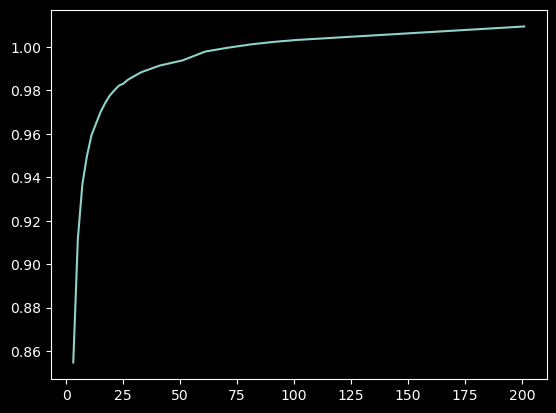

np.float64(3.5096426844389295)

In [157]:
plt.plot(filter_len, (variances) * filter_len / 1)
#plt.plot(filter_len, 1/filter_len)
plt.show()
1.0/variances[0]

In [55]:
f_hist, edges = np.histogram(filtered_samples, bins=50)

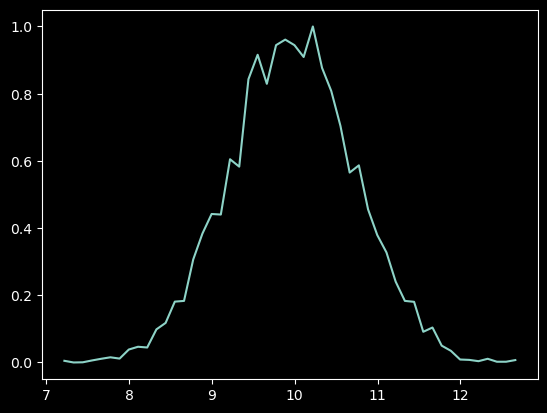

In [56]:
import matplotlib.pyplot as plt
plt.plot(edges[:-1], f_hist/f_hist.max())
plt.show()

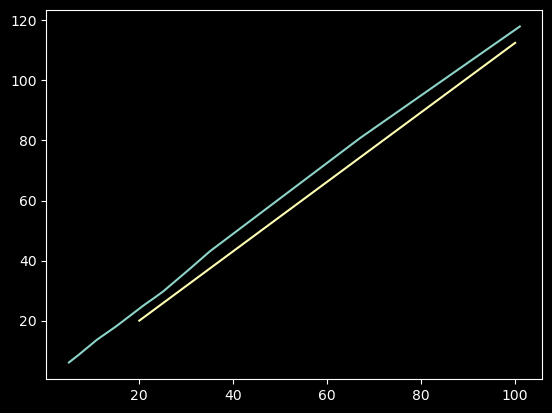

In [105]:
x=[5,7,11,15,21,23,25,31,35,67,101]
y = [.3692,.3115, .2427, .2149,0.182,0.1752,0.1688,0.1481, 0.1374,.1013, .0852]
#plt.plot(x, y)
plt.plot(x, np.sqrt(x)/y)
plt.plot([20,100], [20,112.5])
plt.show()


# Local noise estimation
Suppose we have a local cube of voxels N^3. Our aim is to estimate the voxel noise from non-overlapping sub-cube regions of the cube minus the baseline estimator which could be the punctured mean or median along the z-axis.

In [207]:
from pathlib import Path
import numpy as np
from numpy.typing import NDArray
from cfg_data import AnalysisBase
from noise import fit_mixture_distribution

vol_idx  = 0
cfg_path = Path("../config.toml")
vol = AnalysisBase(cfg_path=cfg_path, vol_index=vol_idx, exp_index=0)

In [220]:
N = 15
z0 = 1000
x0, y0 = 380, 380
sub_vol = vol.vol_for_analysis[z0-N//2:z0+N//2+1, x0-N//2:x0+N//2+1, y0-N//2:y0+N//2+1]
baseline = np.median(sub_vol, axis=0).astype(np.uint8)
res_vol = np.subtract(sub_vol, baseline, dtype=np.int16)
mean, std = (res_vol).mean(), (res_vol).std(ddof=1)
print(f"Init mean and std: {mean:.4f}, {std:.4f}")
mask = np.abs(res_vol - mean) < 3.0 * std
print(f"Masked pixels: {np.sum(~mask)}")
print(f"Residual mean and std: {(res_vol[mask]).mean():.4f}, {(res_vol[mask]).std(ddof=1):.4f}")

Init mean and std: 0.0228, 9.0433
Masked pixels: 10
Residual mean and std: 0.0939, 8.9026


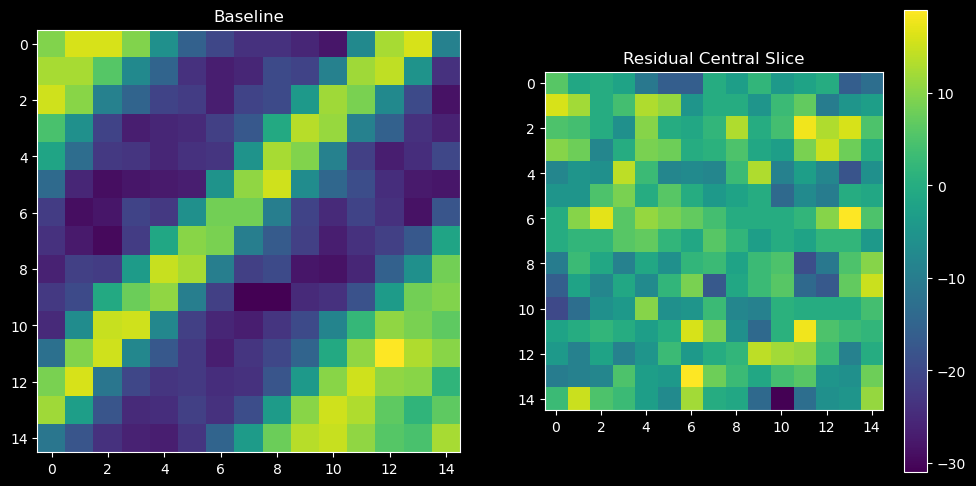

In [217]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(baseline)
plt.title("Baseline")
plt.subplot(1,2,2)
plt.imshow(res_vol[-1].astype(np.int16))
plt.title("Residual Central Slice")
plt.colorbar()
plt.show()

In [218]:
def estimate_regional_sd(
    res_vol: NDArray,
    cube_size: int = 3,
) -> float:
    size = np.asarray(res_vol.shape)
    usable_size = (size // cube_size) * cube_size
    start = (size - usable_size) // 2
    stop = start + usable_size

    cropped = res_vol[
        start[0]:stop[0],
        start[1]:stop[1],
        start[2]:stop[2],
    ]

    nz, ny, nx = cropped.shape
    cubes = cropped.reshape(
        nz // cube_size, cube_size,
        ny // cube_size, cube_size,
        nx // cube_size, cube_size,
    )

    means = cubes.mean(axis=(1, 3, 5)).ravel()

    if means.size < 2:
        return float("nan")

    return float(means.std(ddof=1))
from typing import Any


def estimate_local_noise(
    residual: NDArray[np.floating[Any]],
    background_mask: NDArray[np.bool_],
    *,
    clipping_std_correction: float = 1.0,
    residual_center: float | None = 0.0,
) -> float:
    """Estimate the marginal voxel-noise standard deviation.

    Parameters
    ----------
    residual
        Background-subtracted volume ``R = I - I_background``.
    background_mask
        Boolean mask with the same shape as ``residual``. True values identify
        voxels considered to be background noise; False values identify the
        particle, artifacts, clipped observations, and invalid voxels.
    clipping_std_correction
        Multiplicative correction for the reduction in standard deviation
        caused by clipping. Use 1.0 if the supplied mask does not require a
        clipping correction, or pass the correction factor determined by the
        clipping procedure.
    residual_center
        Expected center of the residual-noise distribution. The default, 0.0,
        is appropriate when the background model has already been subtracted.
        If None, the center is estimated from the selected residuals and the
        variance is calculated with an N-1 denominator.

    Returns
    -------
    float
        Estimated marginal standard deviation of a background voxel, in the
        same intensity units as ``residual``.

    Notes
    -----
    Spatial correlation does not bias the mean squared residual about a known
    center, so no autocorrelation correction is required for voxelwise SNR.
    Correlation does increase the uncertainty of this estimate because the
    effective number of independent observations is smaller than the number
    of selected voxels.

    The returned value is appropriate for constructing the voxelwise
    standardized residual ``Z = residual / sigma``. It is not the noise
    standard deviation of a regional mean, sum, maximum, or filtered response.
    """
    residual = np.asarray(residual, dtype=np.float64)
    background_mask = np.asarray(background_mask, dtype=bool)

    if residual.shape != background_mask.shape:
        raise ValueError(
            "residual and background_mask must have the same shape; "
            f"got {residual.shape} and {background_mask.shape}."
        )

    if not np.isfinite(clipping_std_correction):
        raise ValueError("clipping_std_correction must be finite.")

    if clipping_std_correction <= 0.0:
        raise ValueError("clipping_std_correction must be greater than zero.")

    valid = background_mask & np.isfinite(residual)
    values = residual[valid]

    if values.size == 0:
        raise ValueError("background_mask does not select any finite voxels.")

    if residual_center is None:
        if values.size < 2:
            raise ValueError(
                "At least two valid voxels are required when estimating "
                "the residual center."
            )

        center = float(values.mean())
        variance = float(
            np.sum(np.square(values - center)) / (values.size - 1)
        )
    else:
        center = float(residual_center)

        if not np.isfinite(center):
            raise ValueError("residual_center must be finite or None.")

        # Because the residual center is treated as known, the appropriate
        # denominator is N rather than N - 1.
        variance = float(np.mean(np.square(values - center)))

    return clipping_std_correction * np.sqrt(variance)
std = estimate_local_noise(res_vol, mask, residual_center=None, clipping_std_correction=1.0)
print(f"Estimated std: {std:.4f}")

Estimated std: 9.0196


In [202]:
res_vol.shape

(17, 17, 17)